# 🔬 Exploratory Data Analysis
## Hillel Yaffe Glaucoma Dataset (HYGD)

> **Goal:** Understand the structure, class distribution, quality scores, and visual characteristics of the dataset before modeling.

---

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

# Add src to path
sys.path.insert(0, '../src')

# Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('tab10')

# Paths
DATA_DIR   = Path('../data')
IMAGES_DIR = DATA_DIR / 'Images'
LABELS_CSV = DATA_DIR / 'Labels.csv'

print('Setup complete ✓')

Setup complete ✓


## 1. Load and Inspect Labels

In [2]:
df = pd.read_csv(LABELS_CSV)
print(f'Shape: {df.shape}')
display(df.head(10))
display(df.dtypes)
display(df.isnull().sum().rename('Missing Values'))

Shape: (747, 5)


,Image Name,Patient,Label,Quality Score,Unnamed: 4
0,0_0.jpg,0,GON+,6.18,NaN
1,1_0.jpg,1,GON+,5.31,NaN
2,1_1.jpg,1,GON+,4.37,NaN
3,2_0.jpg,2,GON+,3.51,NaN
4,2_1.jpg,2,GON+,4.24,NaN
5,3_0.jpg,3,GON+,5.95,NaN
6,3_1.jpg,3,GON+,4.22,NaN
7,4_0.jpg,4,GON+,5.25,NaN
8,5_0.jpg,5,GON+,6.58,NaN
9,5_1.jpg,5,GON+,6.67,NaN


Image Name        object
Patient            int64
Label             object
Quality Score    float64
Unnamed: 4       float64
dtype: object

Image Name         0
Patient            0
Label              0
Quality Score      0
Unnamed: 4       747
Name: Missing Values, dtype: int64

In [3]:
print('=== Dataset Summary ===')
print(f"Total images   : {len(df)}")
print(f"Unique patients: {df['Patient'].nunique()}")
print(f"Labels         : {df['Label'].unique()}")
print(f"Quality range  : {df['Quality Score'].min():.1f} – {df['Quality Score'].max():.1f}")
print()
print(df['Label'].value_counts().to_string())
print()
imbalance = df['Label'].value_counts()['GON+'] / df['Label'].value_counts()['GON-']
print(f'Class imbalance ratio (GON+/GON-): {imbalance:.2f}x')

=== Dataset Summary ===
Total images   : 747
Unique patients: 288
Labels         : ['GON+' 'GON-']
Quality range  : 2.0 – 7.7

Label
GON+    548
GON-    199

Class imbalance ratio (GON+/GON-): 2.75x


## 2. Class Distribution

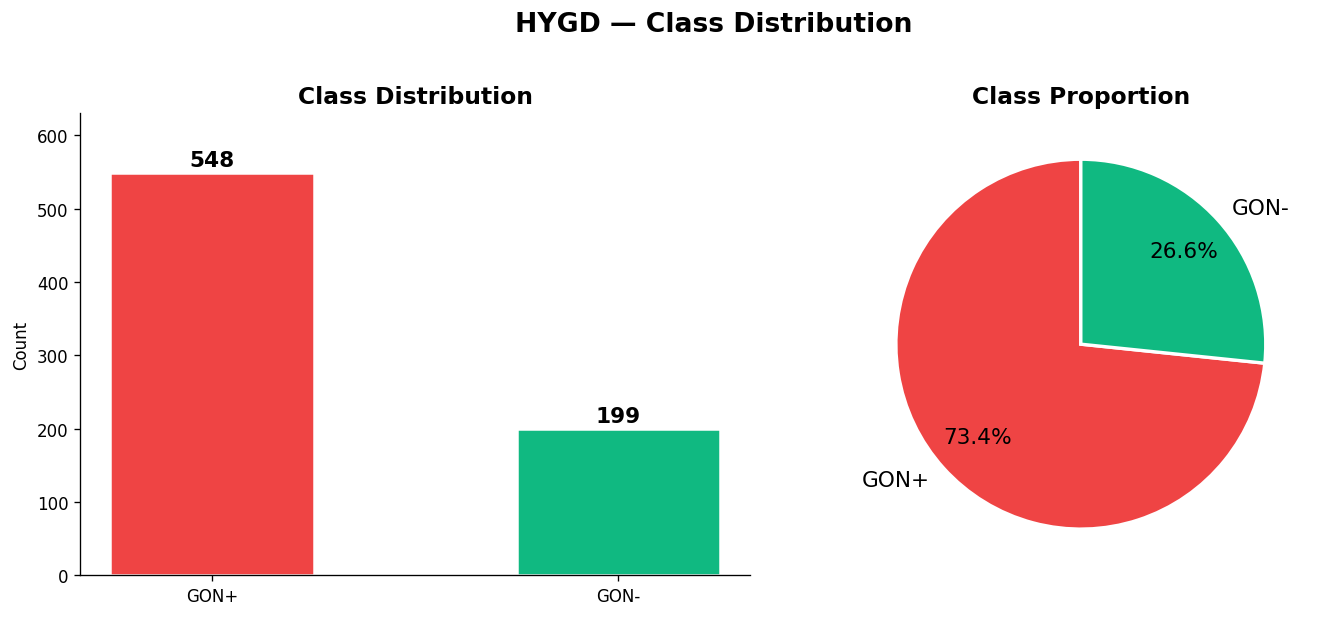

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['Label'].value_counts()
colors = ['#EF4444', '#10B981']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 13}
)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('HYGD — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Quality Score Analysis

In [6]:
print(df['Quality Score'].describe().round(3).to_string())

count    747.000
mean       5.904
std        1.007
min        2.040
25%        5.365
50%        6.180
75%        6.630
max        7.690


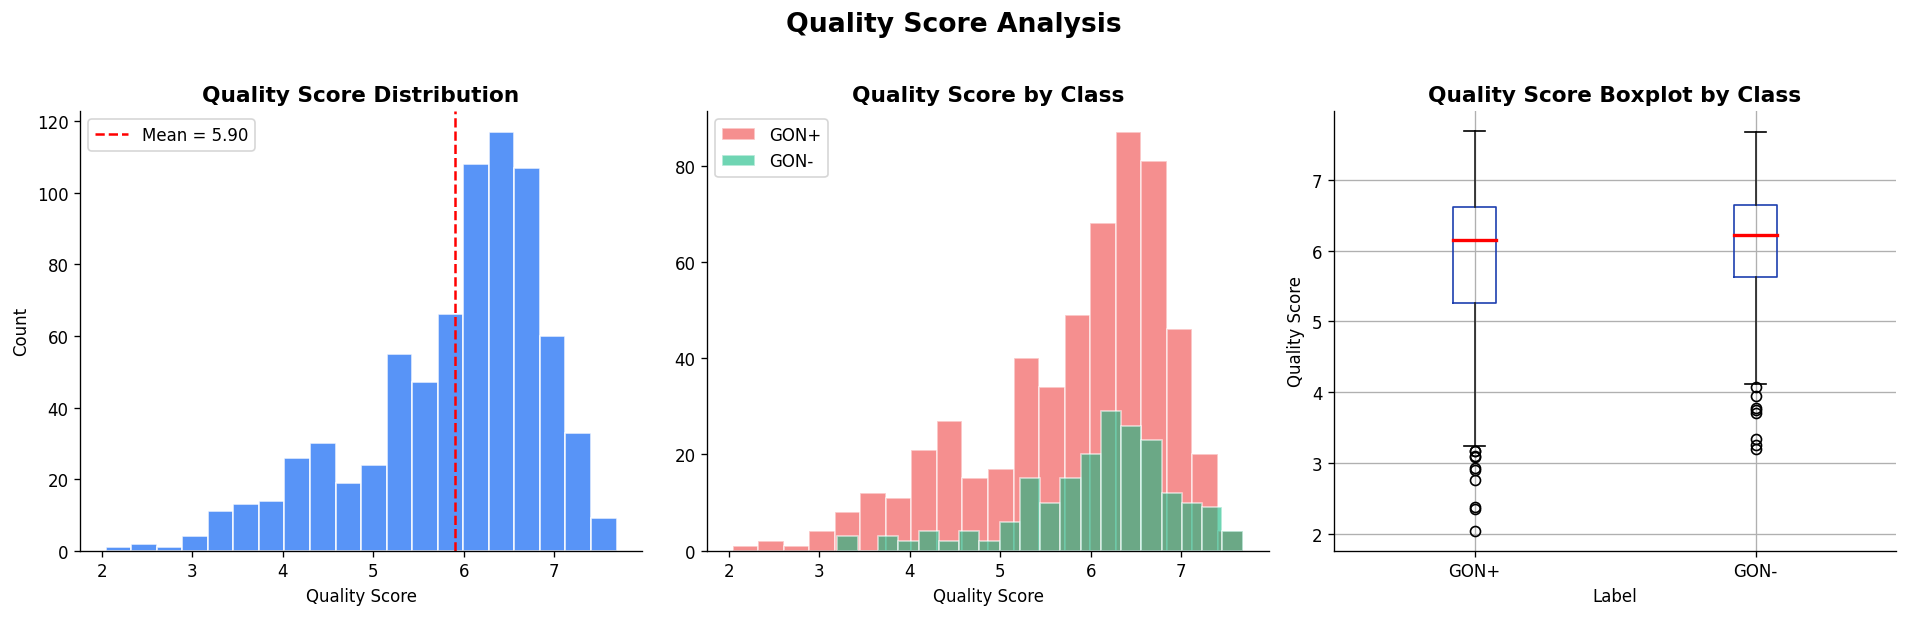

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall distribution
axes[0].hist(df['Quality Score'], bins=20, color='#3B82F6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Quality Score'].mean(), color='red', linestyle='--', label=f"Mean = {df['Quality Score'].mean():.2f}")
axes[0].set_title('Quality Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quality Score'); axes[0].set_ylabel('Count')
axes[0].legend()

# By class
for label, color in zip(['GON+', 'GON-'], ['#EF4444', '#10B981']):
    subset = df[df['Label'] == label]['Quality Score']
    axes[1].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('Quality Score by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quality Score'); axes[1].legend()

# Boxplot
df.boxplot(column='Quality Score', by='Label', ax=axes[2],
           boxprops=dict(color='#1E40AF'), medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Quality Score Boxplot by Class', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Label'); axes[2].set_ylabel('Quality Score')
plt.suptitle('')

plt.suptitle('Quality Score Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Quality filtering impact
print('=== Quality Filtering Impact ===')
for threshold in [1, 2, 3, 4, 5]:
    kept = (df['Quality Score'] >= threshold).sum()
    pct  = kept / len(df) * 100
    print(f"  Quality >= {threshold}: {kept} images ({pct:.1f}% retained)")

=== Quality Filtering Impact ===
  Quality >= 1: 747 images (100.0% retained)
  Quality >= 2: 747 images (100.0% retained)
  Quality >= 3: 741 images (99.2% retained)
  Quality >= 4: 701 images (93.8% retained)
  Quality >= 5: 618 images (82.7% retained)


## 4. Patient-Level Analysis

In [9]:
imgs_per_patient = df.groupby('Patient').size()
print(f'Images per patient:')
print(imgs_per_patient.describe().round(2).to_string())
print(f'\nMax images per patient: {imgs_per_patient.max()}')
print(f'Min images per patient: {imgs_per_patient.min()}')

Images per patient:
count    288.00
mean       2.59
std        1.85
min        1.00
25%        1.00
50%        2.00
75%        3.00
max       14.00

Max images per patient: 14
Min images per patient: 1


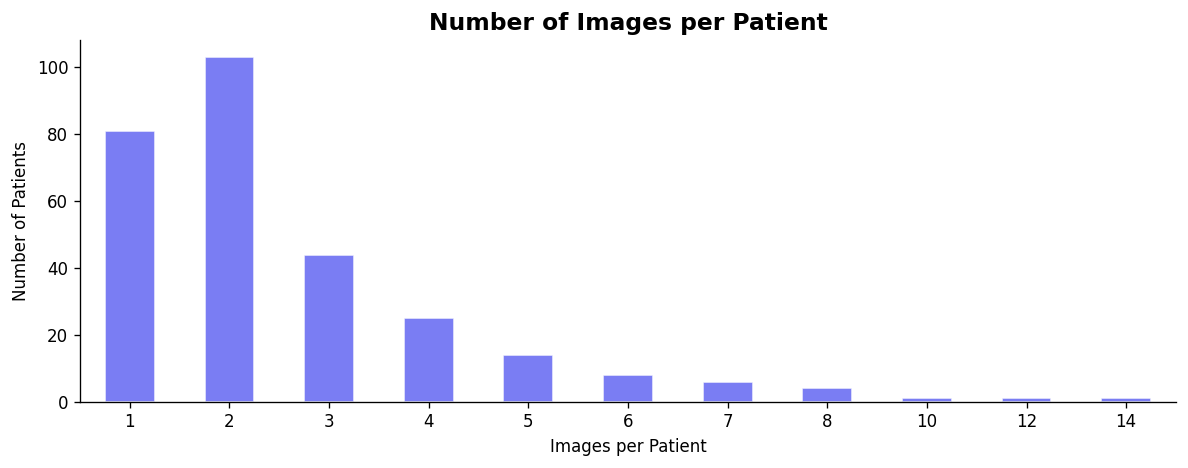

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
imgs_per_patient.value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#6366F1', edgecolor='white', alpha=0.85
)
ax.set_title('Number of Images per Patient', fontsize=14, fontweight='bold')
ax.set_xlabel('Images per Patient'); ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_images_per_patient.png', dpi=150)
plt.show()

## 5. Sample Image Visualization

C:\Users\Admin\AppData\Local\Temp\ipykernel_30608\1485719103.py:10: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
d:\code\kltn\Glaucoma-Detection-from-Deep-Fundus-Images\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


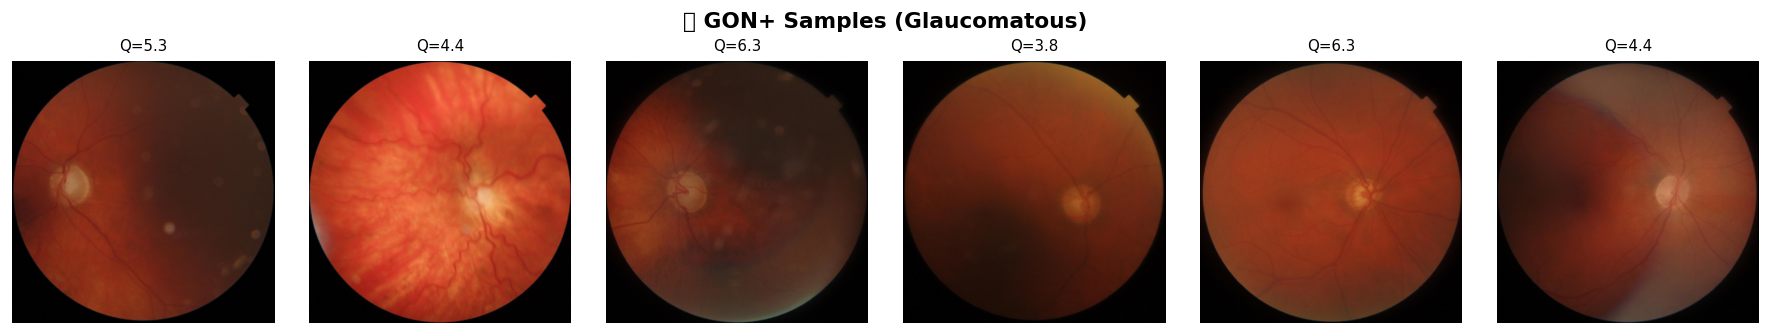

C:\Users\Admin\AppData\Local\Temp\ipykernel_30608\1485719103.py:10: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
d:\code\kltn\Glaucoma-Detection-from-Deep-Fundus-Images\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


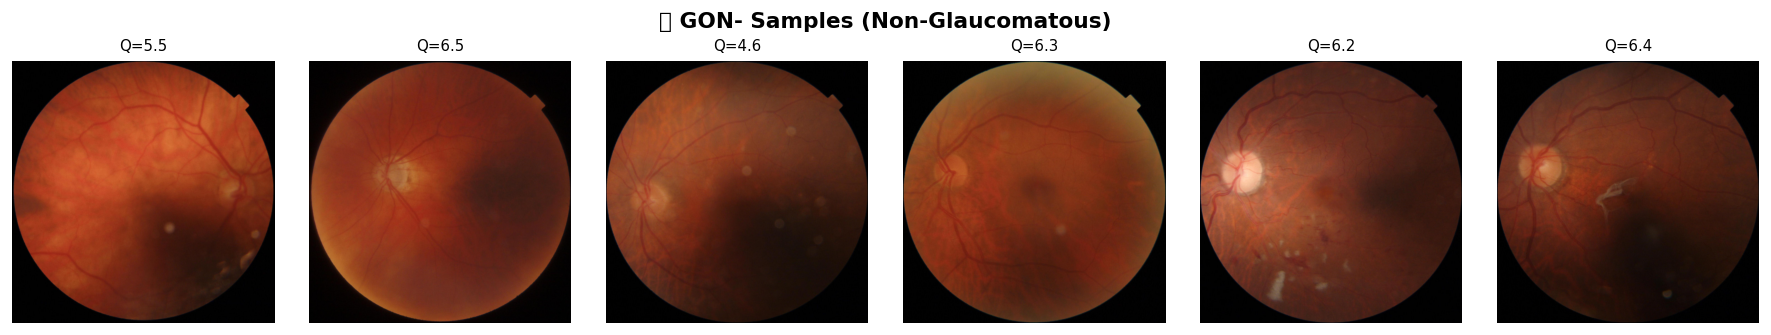

In [11]:
def show_samples(df, label, n=6, title=None):
    subset = df[df['Label'] == label].sample(n, random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 2.8))
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(IMAGES_DIR / row['Image Name']).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"Q={row['Quality Score']:.1f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(title or label, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(df, 'GON+', n=6, title='🔴 GON+ Samples (Glaucomatous)')
show_samples(df, 'GON-', n=6, title='🟢 GON- Samples (Non-Glaucomatous)')

## 6. Image Property Analysis

In [12]:
# Verify aspect ratio and resolution
print('Checking image sizes (first 20 images)...')
sizes = []
for _, row in df.head(20).iterrows():
    img = Image.open(IMAGES_DIR / row['Image Name'])
    sizes.append(img.size)

size_counts = Counter(sizes)
print(f'Unique sizes found: {len(size_counts)}')
for size, count in size_counts.most_common(5):
    print(f'  {size[0]}x{size[1]} px — {count} images')

Checking image sizes (first 20 images)...
Unique sizes found: 16
  1889x1889 px — 3 images
  1940x1940 px — 2 images
  1900x1900 px — 2 images
  1918x1918 px — 1 images
  1929x1929 px — 1 images


## 7. Dataset Split Preview

In [13]:
from dataset import patient_level_split

df_train, df_val, df_test = patient_level_split(df, val_size=0.15, test_size=0.15, seed=42)

split_data = {
    'Split':  ['Train', 'Val', 'Test'],
    'Total':  [len(df_train), len(df_val), len(df_test)],
    'GON+':   [(df_train['Label']=='GON+').sum(), (df_val['Label']=='GON+').sum(), (df_test['Label']=='GON+').sum()],
    'GON-':   [(df_train['Label']=='GON-').sum(), (df_val['Label']=='GON-').sum(), (df_test['Label']=='GON-').sum()],
    'Patients': [df_train['Patient'].nunique(), df_val['Patient'].nunique(), df_test['Patient'].nunique()],
}
split_df = pd.DataFrame(split_data)
display(split_df)

# Verify no patient overlap
train_pts = set(df_train['Patient'])
val_pts   = set(df_val['Patient'])
test_pts  = set(df_test['Patient'])
print(f'\nPatient overlap check:')
print(f'  Train ∩ Val  : {len(train_pts & val_pts)} patients (should be 0)')
print(f'  Train ∩ Test : {len(train_pts & test_pts)} patients (should be 0)')
print(f'  Val ∩ Test   : {len(val_pts & test_pts)} patients (should be 0)')

d:\code\kltn\Glaucoma-Detection-from-Deep-Fundus-Images\.venv\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


,Split,Total,GON+,GON-,Patients
0,Train,523,368,155,200
1,Val,119,100,19,44
2,Test,105,80,25,44



Patient overlap check:
  Train ∩ Val  : 0 patients (should be 0)
  Train ∩ Test : 0 patients (should be 0)
  Val ∩ Test   : 0 patients (should be 0)


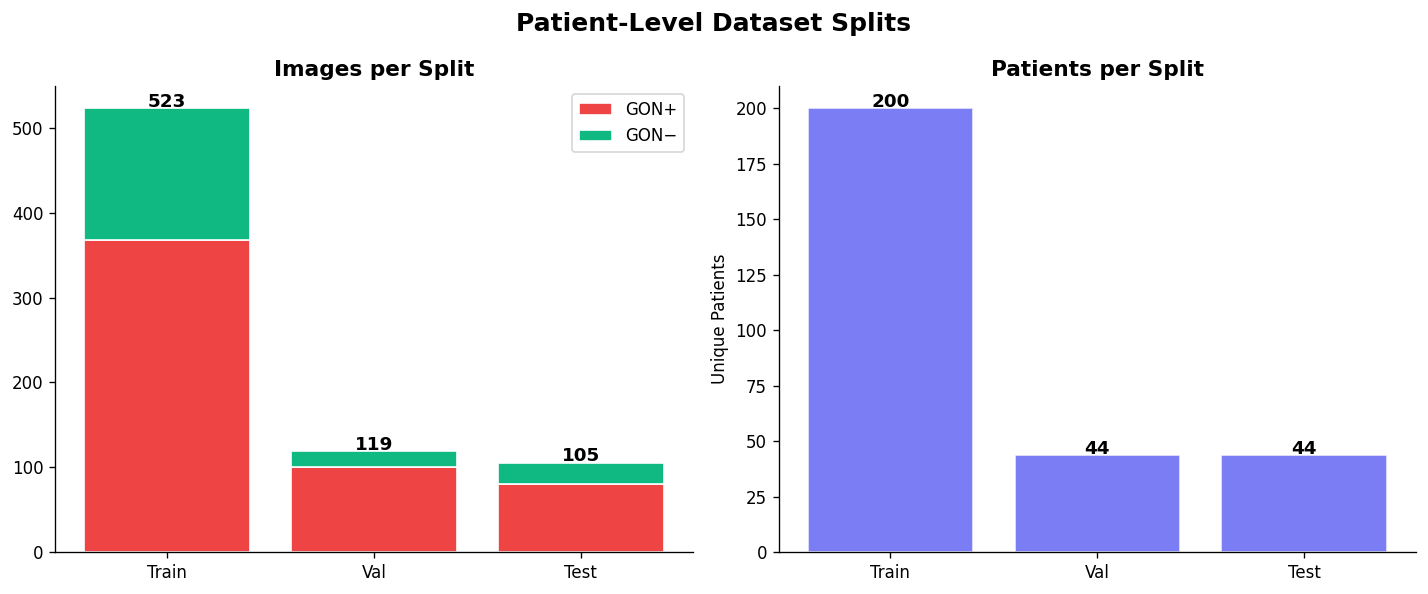

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar by split
x = split_df['Split']
axes[0].bar(x, split_df['GON+'], label='GON+', color='#EF4444', edgecolor='white')
axes[0].bar(x, split_df['GON-'], bottom=split_df['GON+'], label='GON−', color='#10B981', edgecolor='white')
for i, (gp, gn, tot) in enumerate(zip(split_df['GON+'], split_df['GON-'], split_df['Total'])):
    axes[0].text(i, tot + 2, str(tot), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Images per Split', fontsize=13, fontweight='bold')
axes[0].legend()

# Patients per split
axes[1].bar(x, split_df['Patients'], color='#6366F1', edgecolor='white', alpha=0.85)
for i, v in enumerate(split_df['Patients']):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Patients per Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Unique Patients')

plt.suptitle('Patient-Level Dataset Splits', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_splits.png', dpi=150)
plt.show()

## 8. Summary

| Property | Value |
|----------|-------|
| Total images | 747 |
| Unique patients | — |
| GON+ (glaucoma) | 548 (73.4%) |
| GON− (normal) | 199 (26.6%) |
| Class imbalance | ~2.75:1 |
| Quality score range | 1–10 |

### Key Observations

1. **Class Imbalance**: GON+ accounts for ~73% of images — we must use weighted loss or WeightedRandomSampler.
2. **Quality Filtering**: Recommend filtering `Quality Score < 3` to remove extremely noisy images.
3. **Patient Leakage**: Always split at **patient level** to prevent information leakage between splits.
4. **Image Resolution**: All images have a 1:1 aspect ratio — uniform resizing is straightforward.

---
> **Next step:** Run `src/train.py` to begin model training.